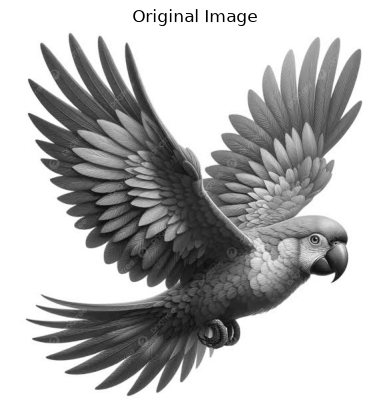

In [5]:
import cv2
import matplotlib.pyplot as plt

# Load the image in grayscale
img = cv2.imread('images/parrot.png', cv2.IMREAD_GRAYSCALE)
plt.imshow(img, cmap='gray')
plt.axis('off')
plt.title('Original Image')
plt.show()

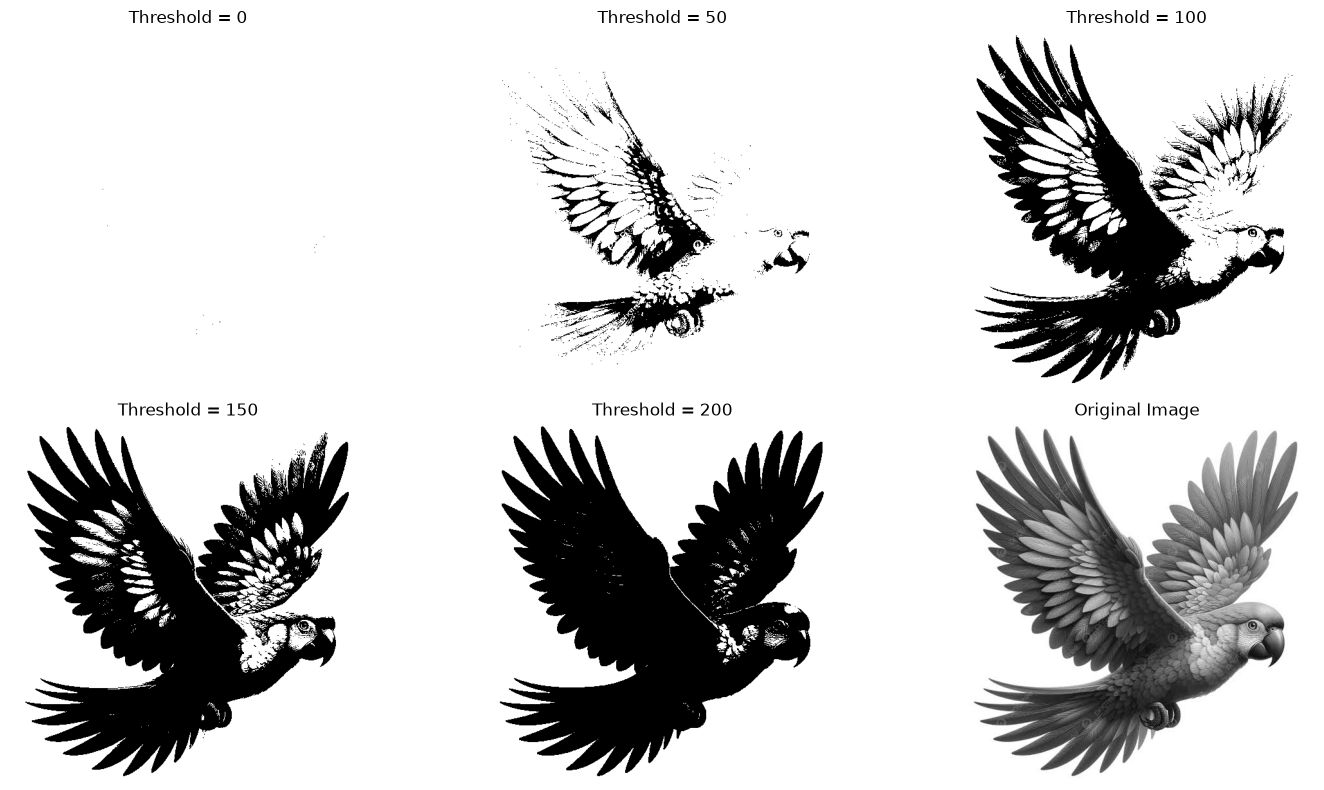

In [6]:
threshold_values = [0, 50, 100, 150, 200]

plt.figure(figsize=(15, 8))

for i, threshold_value in enumerate(threshold_values):
    ret, thresh = cv2.threshold(img, threshold_value, 255, cv2.THRESH_BINARY)

    plt.subplot(2, 3, i + 1)
    plt.imshow(thresh, cmap='gray')
    plt.title(f'Threshold = {threshold_value}')
    plt.axis('off')

plt.subplot(2, 3, 6)
plt.imshow(img, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.tight_layout()
plt.show()

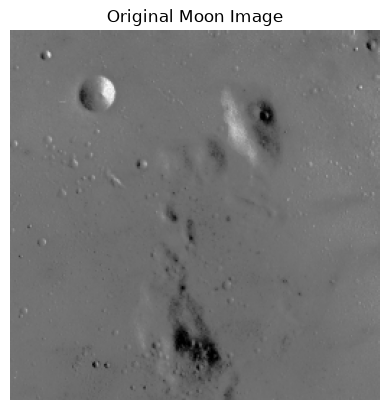

In [7]:
import matplotlib.pyplot as plt
import numpy as np
from skimage import data, exposure

img = data.moon()

plt.imshow(img, cmap='gray')
plt.axis('off')
plt.title('Original Moon Image')
plt.show()

In [8]:
p2, p98 = np.percentile(img, (2, 98))

img_rescale = exposure.rescale_intensity(
    img,
    in_range=(p2, p98)
)

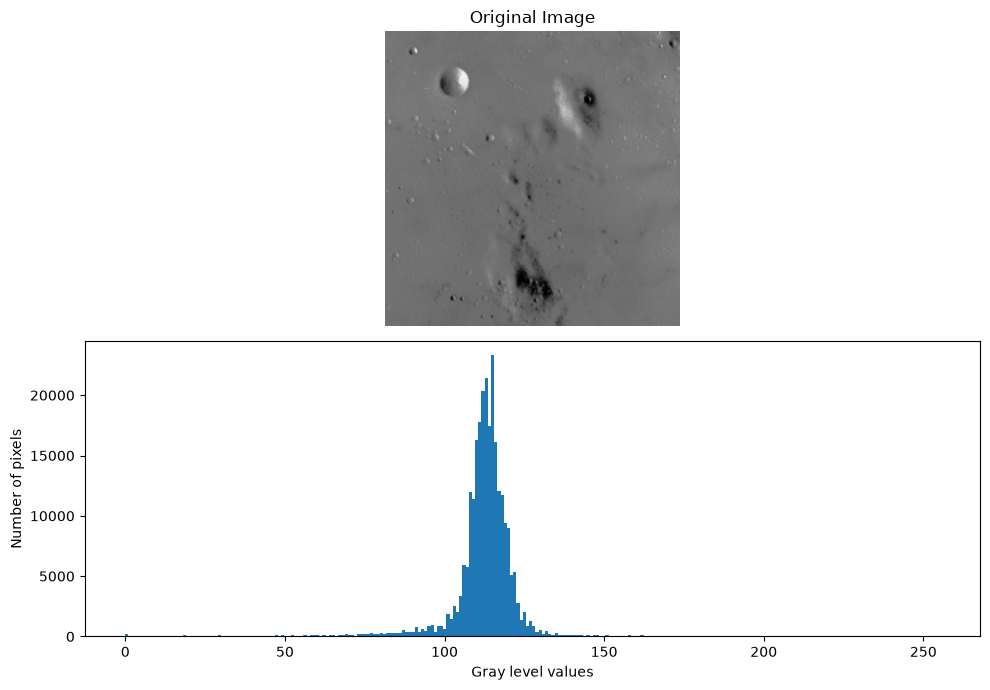

In [9]:
fig = plt.figure(figsize=(10, 7))

fig.add_subplot(2, 1, 1)
plt.imshow(img, cmap='gray')
plt.axis('off')
plt.title('Original Image')

fig.add_subplot(2, 1, 2)
plt.hist(img.flat, bins=256, range=(0, 255))
plt.xlabel('Gray level values')
plt.ylabel('Number of pixels')

plt.tight_layout()
plt.show()

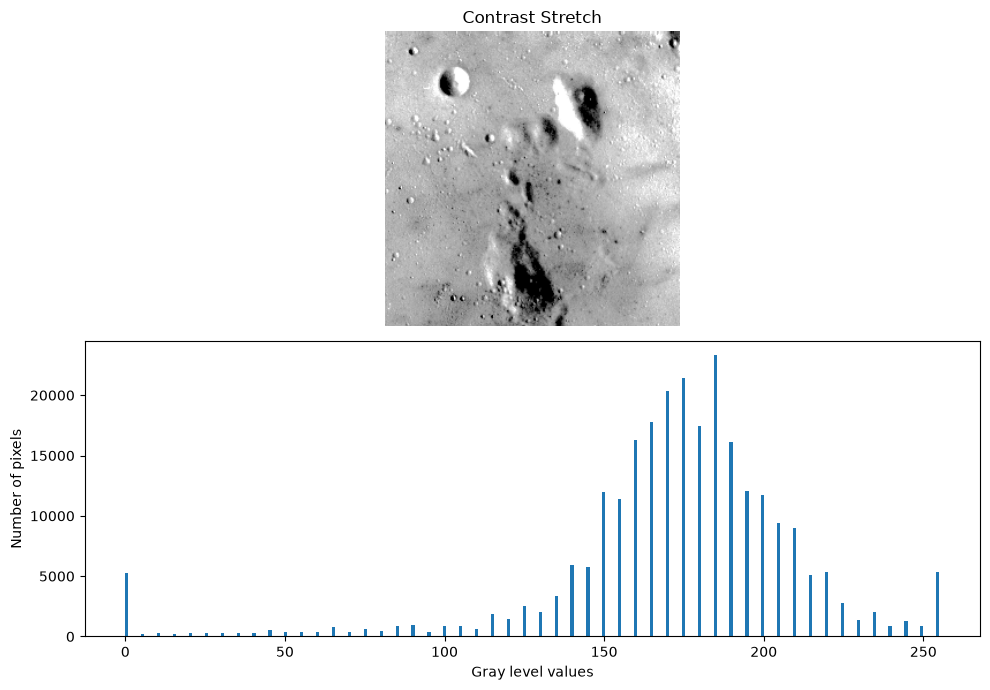

In [10]:
fig = plt.figure(figsize=(10, 7))

fig.add_subplot(2, 1, 1)
plt.imshow(img_rescale, cmap='gray')
plt.axis('off')
plt.title('Contrast Stretch')

fig.add_subplot(2, 1, 2)
plt.hist(img_rescale.flat, bins=256, range=(0, 255))
plt.xlabel('Gray level values')
plt.ylabel('Number of pixels')

plt.tight_layout()
plt.show()

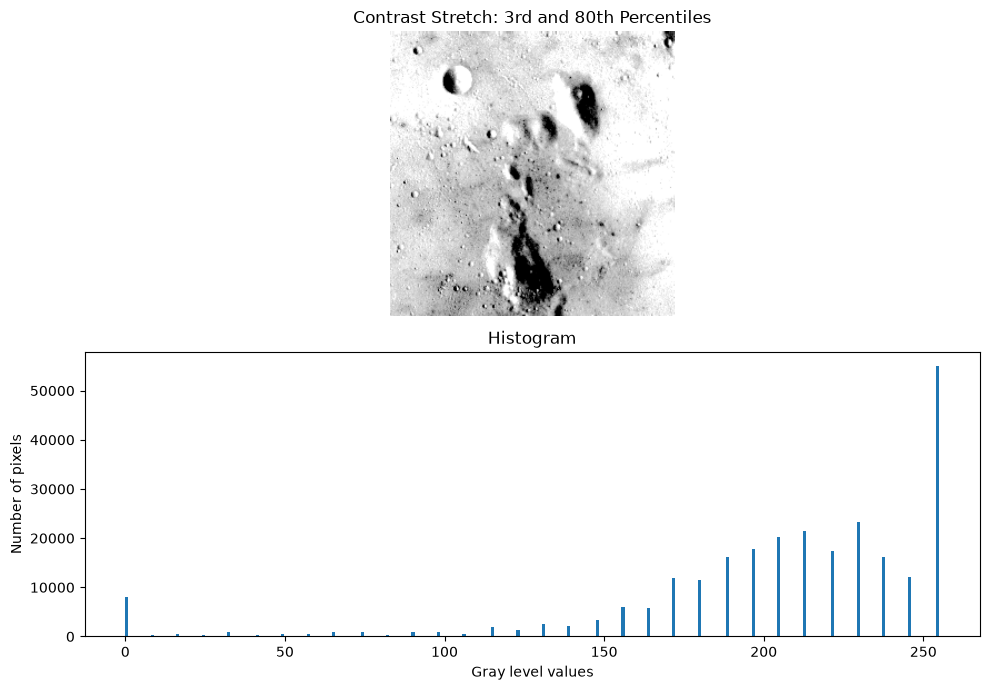

In [11]:
p3, p80 = np.percentile(img, (3, 80))

img_rescale_3_80 = exposure.rescale_intensity(
    img,
    in_range=(p3, p80)
)

plt.figure(figsize=(10, 7))

plt.subplot(2, 1, 1)
plt.imshow(img_rescale_3_80, cmap='gray')
plt.axis('off')
plt.title('Contrast Stretch: 3rd and 80th Percentiles')

plt.subplot(2, 1, 2)
plt.hist(img_rescale_3_80.flat, bins=256, range=(0, 255))
plt.xlabel('Gray level values')
plt.ylabel('Number of pixels')
plt.title('Histogram')

plt.tight_layout()
plt.show()

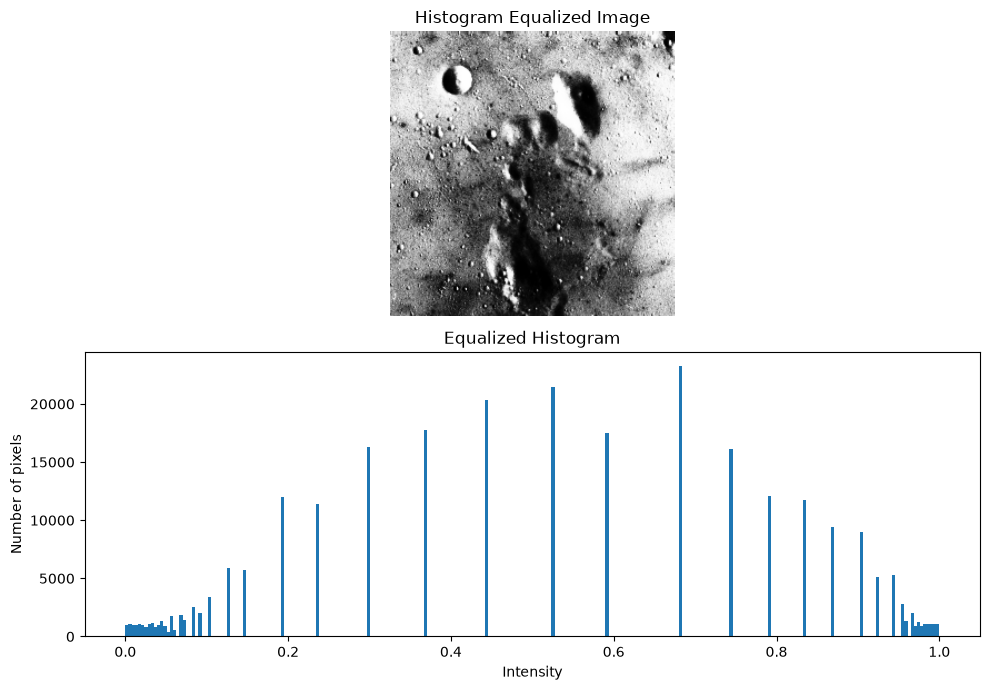

In [12]:
img_equalized = exposure.equalize_hist(img)

plt.figure(figsize=(10, 7))

plt.subplot(2, 1, 1)
plt.imshow(img_equalized, cmap='gray')
plt.axis('off')
plt.title('Histogram Equalized Image')

plt.subplot(2, 1, 2)
plt.hist(img_equalized.flat, bins=256, range=(0, 1))
plt.xlabel('Intensity')
plt.ylabel('Number of pixels')
plt.title('Equalized Histogram')

plt.tight_layout()
plt.show()

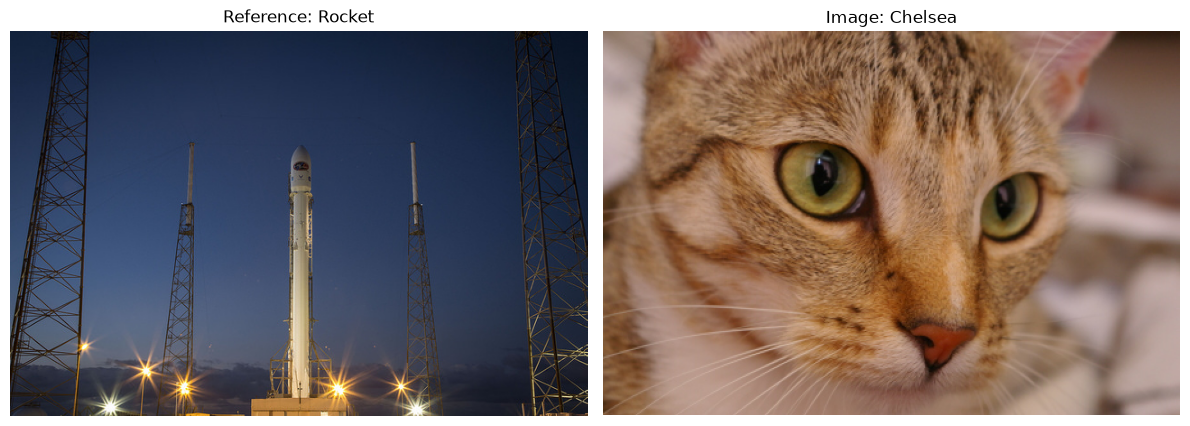

In [13]:
from skimage import data, exposure
import matplotlib.pyplot as plt

reference = data.rocket()
image = data.chelsea()

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(reference)
plt.title('Reference: Rocket')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(image)
plt.title('Image: Chelsea')
plt.axis('off')

plt.tight_layout()
plt.show()

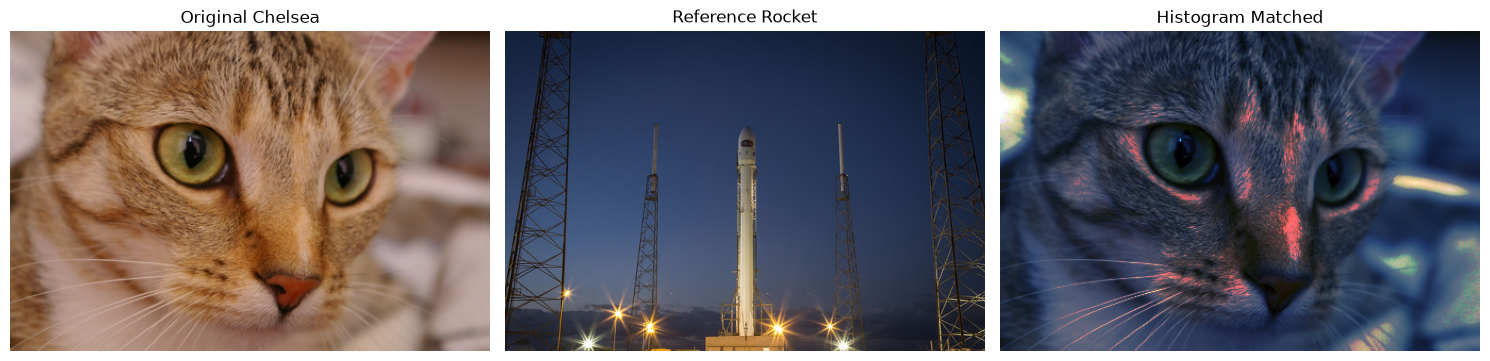

In [14]:
matched = exposure.match_histograms(
    image,
    reference,
    channel_axis=-1
)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(image)
plt.title('Original Chelsea')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(reference)
plt.title('Reference Rocket')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(matched)
plt.title('Histogram Matched')
plt.axis('off')

plt.tight_layout()
plt.show()

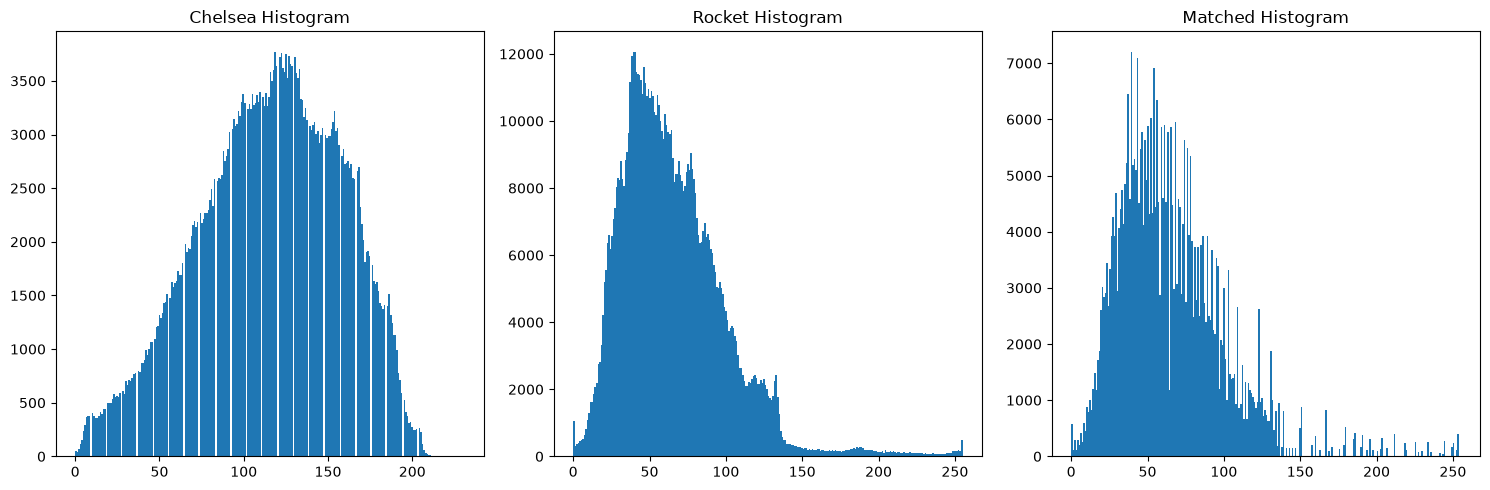

In [15]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.hist(image.ravel(), bins=256)
plt.title('Chelsea Histogram')

plt.subplot(1, 3, 2)
plt.hist(reference.ravel(), bins=256)
plt.title('Rocket Histogram')

plt.subplot(1, 3, 3)
plt.hist(matched.ravel(), bins=256)
plt.title('Matched Histogram')

plt.tight_layout()
plt.show()